# 🏥 AI-Doctor Workshop - Kun jij een computer leren om een litteken te herkennen?

Welkom bij deze workshop over kunstmatige intelligentie! We gaan een computer leren om röntgenfoto's van tanden te bekijken en te bepalen of iemand een litteken heeft gehad of niet.

## 🚀 Hoe werkt dit?

Dit bestand is een *Jupyter Notebook*: een soort digitaal werkboek waar tekst (zoals dit) en programmeercode door elkaar staan. Je kunt de grijze vakjes met code laten draaien door erop te klikken en dan **Shift + Enter** te drukken.

**⚠️ BELANGRIJK:** Begin met het draaien van de cel hieronder, anders werkt niets!

**Lessen:** Je za in deze twee lessen leren
<ul>
<li> hoe een computer een plaatje bewerkt </li>
<li> hoe convoluties patronen herkennen in plaatjes </li>
<li> hoe je een eigen AI-model kan trainen </li>
<li> hoe je de prestaties van je AI-model kan evalueren. </li>
</ul>

# Bouw een AI-tandarts 🦷🤖

Klik op **Run All** (boven in het menu: Runtime → Run All) om de hele notebook uit te voeren.  Het uitvoeren duurt ongeveer **5 minuten**.  Aan de rechter onderkant van je venster zie je wat de status is. Als je computer nog bezig is dan zie je **Executing (xs)**, als deze klaar is dan zie je **Ready**.

Bekijk vooral de **resultaten en grafieken** die verschijnen, en besteed minder aandacht aan de code zelf. De code is er om het model te trainen en te evalueren, maar de inzichten zitten in de output!

ℹ️ **Tip:** Als je het bericht "Lost connection" krijgt, ligt dat meestal aan de wifi.  Klik dan gewoon opnieuw op **Run All** en de notebook zal verder werken!

## 🔄 Opfrissing: Matrices, Convoluties en Neurale Netwerken

Voordat we dieper duiken, hier een korte herhaling van de belangrijke concepten die we eerder hebben besproken:

### 🔢 Matrices: De Bouwstenen van Beelden
*   **Wat zijn het?** Matrices zijn rechthoekige roosters van getallen. Denk aan een spreadsheet. In computerbeelden vertegenwoordigen ze pixels: elk getal is de intensiteit (helderheid of kleurwaarde) van een pixel.
*   **Waarom belangrijk?** Computers 'zien' afbeeldingen niet zoals wij; ze zien alleen matrices vol getallen. AI-modellen werken direct met deze getallen.

### 🌀 Convoluties: Patronen Herkennen in Beelden
*   **Wat is het?** Een convolutie is een wiskundige operatie waarbij een kleiner 'filter' of 'kernel' over een grotere matrix (jouw afbeelding) schuift. Op elke positie berekent het een nieuwe waarde door de getallen in het filter te vermenigvuldigen met de corresponderende getallen in de afbeelding en deze op te tellen.
*   **Waarom belangrijk?** Convoluties zijn de 'ogen' van de AI. Ze helpen de AI om specifieke patronen te herkennen, zoals randen, texturen of vormen in een afbeelding. Verschillende filters kunnen verschillende patronen detecteren.

### 🧠 Neurale Netwerken: Het AI-Brein
*   **Wat zijn het?** Een neuraal netwerk is een complex systeem van onderling verbonden 'neuronen' (wiskundige functies) die informatie verwerken. Ze zijn losjes gebaseerd op de structuur van het menselijk brein.
*   **Hoe werken ze?** Informatie stroomt door lagen van neuronen, waarbij elke verbinding een 'gewicht' heeft. Tijdens het trainen passen de netwerken deze gewichten aan om te leren van voorbeelden en steeds betere beslissingen te nemen.
*   **Waarom belangrijk?** De output van convoluties (de herkende patronen) wordt ingevoerd in een neuraal netwerk, dat vervolgens een uiteindelijke beslissing neemt, zoals 'litteken aanwezig' of 'geen litteken'.

### Programmatje 1: Tools importeren

Druk op het Run knopje hieronder om dit programma uit te voeren. Dit programma laad alle nodige bibliotheken.

In [1]:
# 📦 Alle tools en bibliotheken laden die we nodig hebben
# Dit is zoals het uitpakken van een gereedschapskist

import pip

import numpy as np
import os
from glob import glob
import torch
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import torch.nn.functional as F

print("🔧 Installeren van speciale medische data tools...")
%pip install medmnist

print("🔧 Installeren van tools voor medische beelden...")
%pip install SimpleITK
import SimpleITK as sitk

print("📂 Downloaden van voorbeeld bestanden...")
!git clone https://github.com/NicosStarreveld/WorkshopCNNs.git

print("✅ Alles klaar! Laten we beginnen!")

🔧 Installeren van speciale medische data tools...
🔧 Installeren van tools voor medische beelden...
📂 Downloaden van voorbeeld bestanden...
fatal: destination path 'WorkshopCNNs' already exists and is not an empty directory.
✅ Alles klaar! Laten we beginnen!


## 🤖 Hoe kan een computer beelden "zien"?

Stel je voor: je bent tandarts en elke dag moet je tientallen röntgenfoto's bekijken om te zien of patiënten een litteken hebben gehad. Na een paar uur word je moe en kun je dingen over het hoofd zien. Maar wat als een computer je kon helpen die nooit moe wordt?

## 🎯 Onze missie vandaag:
We gaan een slimme computer maken die automatisch kan zien of iemand een litteken heeft gehad op een röntgenfoto.

**Fun fact:** Computers zijn soms zelfs beter dan mensen in het herkennen van bepaalde patronen op medische foto's! 🤯

<span style="color:blue">

### Programmatje 2: Afbeeldingen openen

Voer dit programma uit om afbeeldingen te kunnen openen en bekijken

</span>

In [2]:
# 🛠️ Handige functies om afbeeldingen te openen en te bekijken

from PIL import Image

def open_img(path):
    """Deze functie opent een afbeelding - zoals het openen van een boek!"""
    if path.endswith(('.png', '.jpg', '.jpeg')):
        return np.array(Image.open(path).convert('L'))
    elif path.endswith('.mhd'):
        return sitk.GetArrayFromImage(sitk.ReadImage(path))[32,:,:] # return 1 slice of the image
    return None # Return None if the file type is not supported

def visualize(img, clim=[-300,450]):
    """Deze functie laat een afbeelding zien - zoals het aandoen van het licht!"""
    plt.imshow(img, cmap='gray', clim=clim)
    plt.axis('off')  # Geen getallen op de randen
    plt.show()

print("🎨 Functies geladen! Klaar om afbeeldingen te bekijken!")

🎨 Functies geladen! Klaar om afbeeldingen te bekijken!


🏥 Laden van een röntgenfoto van de tand...
✨ Hier is de röntgenfoto:


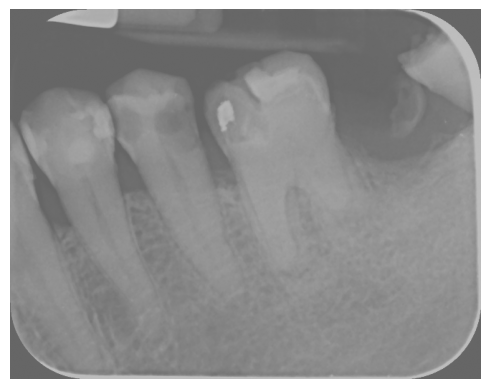


🤔 Dit is hoe een computer deze foto 'ziet', een tabel vol getallen


In [3]:
# 📸 Laten we onze eerste medische afbeelding bekijken!

print("🏥 Laden van een röntgenfoto van de tand...")

# Het pad naar onze afbeelding
img_path = 'WorkshopCNNs/Xrays_without_lesion/athanasopoulou__1.jpg'
img = open_img(img_path)

print("✨ Hier is de röntgenfoto:")
visualize(img)

print("\n🤔 Dit is hoe een computer deze foto 'ziet', een tabel vol getallen")

## 🧠 Van simpele trucjes naar echte AI!

**Plot twist!** 🎬 Wat we net gedaan hebben zijn de **bouwstenen** van kunstmatige intelligentie!

### 🏗️ Hoe bouw je een AI-dokter?

1. **Stap 1:** Begin met simpele convoluties (zoals we net deden)
2. **Stap 2:** Stapel er tientallen, soms honderden van bovenop elkaar!
3. **Stap 3:** Laat de computer zelf uitvogelen welke kernels het beste werken
4. **Stap 4:** Train het met voorbeelden van foto's met en zonder een litteken

### 🤯 Het belangrijkste deel:
De computer bedenkt zelf de beste kernels! Wij geven hem alleen voorbeelden en hij leert:
"Ah, als ik deze kernel gebruik, kan ik een litteken herkennen!"

**Dit noemen we een Convolutional Neural Network (CNN)** - een neuraal netwerk dat gespecialiseerd is in het begrijpen van afbeeldingen.

Klaar voor de echte AI? 🚀

## 🏥 Onze missie: De AI-dokter trainen

**Het verhaal:** Er zijn 340 röntgenfoto's van tanden: sommige van mensen met een litteken, andere van mensen zonder. Voor een dokter is het soms moeilijk om het verschil te zien, vooral na een lange dag vol patiënten.

### 🎯 Ons Doel:
We gaan een slimme computer trainen die in één oogopslag kan zeggen:
- 💚 **"Deze patient heeft geen litteken!"**  
- 🔴 **"Deze patient heeft wel een litteken!"**

### 📊 Onze Data:
We gebruiken een **dataset** gemaakt door tandsartsen- dat zijn honderden kleine röntgenfoto's die al gelabeld zijn door echte dokters.

Laten we beginnen! 🚀

### 🎓 Training: De AI leert van voorbeelden

Stel je voor dat je een kind leert om het verschil te zien tussen een hond en een kat. Je laat het kind heel veel foto's zien van honden en katten, en bij elke foto vertel je of het een hond of een kat is. Na een tijdje leert het kind zelf de kenmerken te herkennen die bij een hond horen en die bij een kat. Dit is precies wat er gebeurt tijdens de trainingsfase:

*   **De AI krijgt trainingsdata:** Dit zijn de röntgenfoto's waar we al van weten of er een litteken op staat of niet (de 'labels').
*   **De AI maakt een voorspelling:** De AI probeert te raden of een litteken aanwezig is.
*   **De AI vergelijkt met het 'echte' antwoord:** De `loss_function` meet hoe groot het verschil is tussen de voorspelling van de AI en het correcte antwoord (de 'fout').
*   **De AI leert van de fout:** De `optimizer` gebruikt deze fout om de interne parameters (de 'kernels' en gewichten) van de AI heel kleine beetje aan te passen, zodat de volgende keer de voorspelling beter is. Dit proces herhaalt zich duizenden keren over vele 'epochs'.

### Programmatje 3: Scans in juiste format zetten!

In [4]:
# 📦 Scans in juiste format zetten!

import cv2
from sklearn.model_selection import train_test_split

images = []
labels = []
orig_images = []

for filename in os.listdir("WorkshopCNNs/X_rays_with_lesion"):
  if 'ipynb' in filename: continue
  orig = cv2.imread(f"WorkshopCNNs/X_rays_with_lesion/{filename}", cv2.IMREAD_GRAYSCALE)
  img = cv2.resize(orig, (128, 128))
  img = img.astype(np.uint8)

  orig_images.append(orig)
  images.append(img)
  labels.append([1])

for filename in os.listdir("WorkshopCNNs/Xrays_without_lesion"):
  if 'ipynb' in filename: continue
  orig = cv2.imread(f"WorkshopCNNs/Xrays_without_lesion/{filename}", cv2.IMREAD_GRAYSCALE)
  img = cv2.resize(orig, (128, 128))
  img = img.astype(np.uint8)

  orig_images.append(orig)
  images.append(img)
  labels.append([0])

images = np.array(images)
labels = np.array(labels)
orig_images = np.array(orig_images, dtype=object)

# Split resized images AND original images together
X_train, X_temp, X_train_orig, X_temp_orig, y_train, y_temp = train_test_split( images, orig_images, labels, test_size=0.3 )
X_val, X_test, X_val_orig, X_test_orig, y_val, y_test = train_test_split( X_temp, X_temp_orig, y_temp, test_size=0.5 )

# Opslaan in MedMNIST-formaat
np.savez("teethmnist.npz",
         train_images=X_train, train_labels=y_train, train_orig=X_train_orig,
         val_images=X_val, val_labels=y_val, val_orig=X_val_orig,
         test_images=X_test, test_labels=y_test, test_orig=X_test_orig)

In [5]:
from torch.utils.data import Dataset

class TeethMNIST(Dataset):
  def __init__(self, split="train", transform=None):
      data = np.load("teethmnist.npz", allow_pickle=True)

      self.images = data[f"{split}_images"]
      self.labels = data[f"{split}_labels"]
      self.orig_images = data[f"{split}_orig"] # original images

      self.transform = transform

  def __len__(self):
      return len(self.images)

  def __getitem__(self, idx):
      img = self.images[idx].astype(np.float32)/255.0
      img = np.clip(img * 1.2, 0, 255)
      orig = self.orig_images[idx]
      label = int(self.labels[idx])

      # Add channel dimension: (1, H, W)
      img = np.expand_dims(img, axis=0)
      img = torch.tensor(img)

      if self.transform:
          img = self.transform(img)

      return {
          "img": img, # tensor → batched
          "label": label, # scalar → batched
          "orig": orig # numpy → ignored by collate
          }

## ✨ Bonustoelichting voor diegenen die willen meer verdieping: Data-augmentatie: Meer data met slimme trucjes
Voor wiskundeleraren kan data-augmentatie gezien worden als het toepassen van **transformaties** op de bestaande dataset om nieuwe, maar toch realistische, datapunten te genereren. Dit helpt om de **robuustheid** en **generaliseerbaarheid** van het AI-model te verbeteren.

### 🤔 Waarom is dit belangrijk vanuit een wiskundig perspectief?

1.  **Vergroten van de dataset:** Vaak hebben we niet genoeg unieke trainingsvoorbeelden. Door transformaties toe te passen, creëren we effectief een grotere dataset zonder nieuwe data te hoeven verzamelen. Dit vermindert de kans op **overfitting**, waarbij het model de trainingsdata 'uit het hoofd leert' in plaats van algemene patronen te herkennen.

2.  **Invariante eigenschappen leren:** Door bijvoorbeeld rotaties of verschuivingen toe te passen, leert het model dat een litteken er nog steeds uitziet als een litteken, ongeacht de exacte oriëntatie of positie op de röntgenfoto. Dit is vergelijkbaar met het leren van **invariante transformaties** in de meetkunde.

3.  **Regularisatie:** Data-augmentatie fungeert als een vorm van **regularisatie**. Het introduceert kleine verstoringen in de trainingsdata, waardoor het model minder gevoelig wordt voor specifieke ruis of variaties in de input. Wiskundig gezien helpt dit om de **complexiteit** van het model te beheersen en te voorkomen dat het te veel 'afstemt' op de idiosyncrasieën van de trainingsset.

4.  **Optimalisatie van de kostenfunctie:** Door een bredere variatie aan data te presenteren, wordt de **kostenfunctie** (die de fout van het model meet) gladder en minder gevoelig voor lokale minima, wat de **optimalisatie** van het neurale netwerk vergemakkelijkt.

Deze transformaties omvatten vaak:

*   **Rotaties:** De afbeelding wordt gedraaid over een bepaalde hoek.
*   **Verschuivingen (translations):** De afbeelding wordt horizontaal of verticaal verplaatst.
*   **Spiegelingen (flips):** De afbeelding wordt horizontaal of verticaal gespiegeld.
*   **Schaalveranderingen (scaling):** De afbeelding wordt vergroot of verkleind.

Elk van deze operaties kan worden beschreven met **transformatie-matrices** in de lineaire algebra, wat een directe link legt met bekende wiskundige concepten.

In [6]:
import medmnist
%pip install monai

In [7]:
import monai
from monai.transforms import Compose, RandRotate, RandFlip, RandZoom, NormalizeIntensity

# 1. Define the "Gym" (Training with Augmentation)
train_transform = Compose([
    RandRotate(range_x=0.4, prob=0.7, keep_size=True),
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    NormalizeIntensity(subtrahend=.5, divisor=.5)
])

# 2. Define the "Test Center" (Validation/Test without Augmentation)
val_transform = NormalizeIntensity(subtrahend=.5, divisor=.5)

# Apply 'train_transform' to train, and 'val_transform' to the others
train_dataset = TeethMNIST(split="train", transform=train_transform) # <--- USE THE NEW ONE
val_dataset = TeethMNIST(split="val", transform=val_transform)
test_dataset = TeethMNIST(split="test", transform=val_transform)
# -----------------------

def collate_without_orig(batch):
    batch_no_orig = []
    for sample in batch:
        sample = {k: v for k, v in sample.items() if k != "orig"}
        batch_no_orig.append(sample)
    return monai.data.utils.list_data_collate(batch_no_orig)

train_dataloader = monai.data.DataLoader(train_dataset, batch_size=16, shuffle=True,
                                         collate_fn=collate_without_orig)
val_dataloader = monai.data.DataLoader(val_dataset, batch_size = 16, shuffle=False,
                                       collate_fn=collate_without_orig)


print(f"✅ Training dataset klaar! {len(train_dataset)} foto's zijn gereed voor AI training (met augmentatie)!")
print("🎓 Nu kan onze computer leren wat het verschil is tussen tanden met en zonder een kanaalbehandeling!")

✅ Training dataset klaar! 340 foto's zijn gereed voor AI training (met augmentatie)!
🎓 Nu kan onze computer leren wat het verschil is tussen tanden met en zonder een kanaalbehandeling!


## 📊 Belangrijke vraag: Is onze dataset gebalanceerd?

Stel je voor: je wilt leren om appels en peren te herkennen, maar je trainingsset heeft 1000 appels en maar 10 peren. Dan wordt je AI heel goed in appels herkennen, maar slecht in peren!

### 🤔 De Balance-Check:
We gaan kijken of onze dataset **gebalanceerd** is. Hebben we evenveel foto's met een litteken als zonder? Of is er een grote scheefheid?

### 🎯 Waarom is dit belangrijk?
- Als er veel meer foto's zijn met een litteken, denkt de AI misschien dat iedereen een litteken heeft gehad.
- Als er veel meer foto's zijn zonder, mist de AI misschien echte littekens.

Laten we het uitzoeken! 👇

### Programmatje 4: Dataset Balance Check!

In [8]:
# 📊 Dataset Balance Check!


print("\n🔍 Nu gaan we de hele dataset analyseren...")
print("   Tellen hoeveel foto's er zijn van elke categorie...")

# Tel alle labels
counts = {0: 0, 1: 0}
for sample in train_dataset:
    counts[sample['label']] += 1

print(f"\n📊 RESULTATEN:")
print(f"   💚 Geen litteken (label 0): {counts[0]:,} foto's")
print(f"   🔴 Met litteken (label 1): {counts[1]:,} foto's")

# Bereken percentages
totaal = counts[0] + counts[1]
percentage_zonder = (counts[0] / totaal) * 100
percentage_met = (counts[1] / totaal) * 100

print(f"\n📈 PERCENTAGES:")
print(f"   💚 {percentage_zonder:.1f}% Foto's zonder litteken")
print(f"   🔴 {percentage_met:.1f}% Foto's met litteken")

if abs(percentage_zonder - percentage_met) < 10:
    print("\n✅ Dataset is goed gebalanceerd! 👍")
elif counts[1] > counts[0]:
    print(f"\n⚠️  Dataset is scheef! Er zijn meer foto's met een litteken.")
    print("   Dit kan onze AI beïnvloeden en leiden tot een voorkeur voor deze klasse.")
else:
    print(f"\n⚠️  Dataset is scheef! Er zijn meer foto's zonder een litteken.")
    print("   Dit kan onze AI beïnvloeden en leiden tot een voorkeur voor deze klasse.")


🔍 Nu gaan we de hele dataset analyseren...
   Tellen hoeveel foto's er zijn van elke categorie...


/tmp/ipykernel_12896/2404688601.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])



📊 RESULTATEN:
   💚 Geen litteken (label 0): 166 foto's
   🔴 Met litteken (label 1): 174 foto's

📈 PERCENTAGES:
   💚 48.8% Foto's zonder litteken
   🔴 51.2% Foto's met litteken

✅ Dataset is goed gebalanceerd! 👍


## 🧠 Stap 3: Tijd om onze AI-dokter te bouwen

Nu komt het spannende gedeelte - we gaan ons **Convolutional Neural Network** (CNN) bouwen! Dit is ons AI-brein dat gaat leren om kanaalbehandeling te herkennen.

### 🏗️ Onze AI-Architectuur:
1. **Laag 1:** 32 verschillende convolutie-filters (32 verschillende "vergrootglazen")
2. **Laag 2:** 64 nog slimmere filters
3. **Laag 3:** 128 extra filters
4. **Hersenen:** Een neuraal netwerk dat de finale beslissing maakt

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Layer 1: 128x128 -> 64x64
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # Layer 2: 64x64 -> 32x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Layer 3: 32x32 -> 16x16
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # Math: 128 channels * 16 * 16 = 32768
        self.fc1 = nn.Linear(32768, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Becomes 64x64
        x = self.pool(F.relu(self.conv2(x))) # Becomes 32x32
        x = self.pool(F.relu(self.conv3(x))) # Becomes 16x16

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# Maak onze AI
print("\n🤖 Creëren van onze AI-Dokter...")
net = Net()
print("🎉 AI-Dokter succesvol gebouwd!")

print(f"\n🧮 Fun fact: Onze AI heeft {sum(p.numel() for p in net.parameters()):,} parameters om te leren!")
print("   Dat zijn heel veel getallen die perfect afgesteld moeten worden! 🤯")


🤖 Creëren van onze AI-Dokter...
🎉 AI-Dokter succesvol gebouwd!

🧮 Fun fact: Onze AI heeft 4,287,233 parameters om te leren!
   Dat zijn heel veel getallen die perfect afgesteld moeten worden! 🤯


## 🎯 De leerregels Instellen

Nu moeten we onze AI leren **hoe** het kan leren! Hiervoor hebben we een paar belangrijke ingrediënten nodig:

### 📏 Loss Functie (Foutmeter):
Dit is hoe we de AI vertellen of het goed of fout zit. We gebruiken **Binary Cross-Entropy Loss**: een fancy naam voor "meet hoe ver je antwoord van de waarheid afzit".

### 🔧 Optimizer (Leeralgoritme):
Dit is de "leraar" die de AI helpt om beter te worden door te vertellen hoe de kernels aangepast kunnen worden. **Adam** is een slimme leraar die weet wanneer grote en kleine aanpassingen nodig zijn.

Denk aan het als het leren fietsen: de loss functie zegt "je valt om!", en de optimizer zegt "probeer je stuur iets meer naar links te draaien". 🚴‍♀️

In [10]:
# 🎓 De training

from tqdm import tqdm
# functie om het model te trainen

def train_medmnist(model, train_dataloader, val_dataloader, optimizer, epochs, device='cuda', val_freq=1):
    train_loss = []
    val_loss = []

    for epoch in tqdm(range(epochs)):
        # model in train modus
        model.train()
        steps = 0
        epoch_loss = 0
        # loop over de batches in training data
        for batch in train_dataloader:
            optimizer.zero_grad()
            images = batch['img'].float().to(device)
            labels = batch['label'].float().to(device)
            labels = labels.unsqueeze(1)
            # haal plaatjes door het model
            output = model(images)
            # bereken de loss tussen de targets en de outputs van het model
            loss = loss_function(output, labels)
            epoch_loss += loss.item()
            # back propagation, update de weights in het netwerk
            loss.backward()
            optimizer.step()
            steps += 1

        train_loss.append(epoch_loss/steps)

        # validation loop
        if epoch % val_freq == 0:
            steps = 0
            val_epoch_loss = 0
            model.eval()
            for batch in val_dataloader:
                images = batch['img'].float().to(device)
                labels = batch['label'].float().to(device)
                labels = labels.unsqueeze(1)
                output = model(images)
                loss = loss_function(output, labels)
                val_epoch_loss += loss.item()
                steps += 1
            val_loss.append(val_epoch_loss/steps)

    # plot the losses together
    plt.plot(train_loss, label='train loss')
    plt.plot(np.arange(0, epochs, val_freq), val_loss, label='val loss')
    plt.legend()
    plt.show()

    return model, train_loss, val_loss

print("🛠️ Training functie geladen en klaar voor gebruik!")

🛠️ Training functie geladen en klaar voor gebruik!


### 🛡️ Overfitting voorkomen met Validatie:

Een van de grootste uitdagingen bij het trainen van AI is 'overfitting'. Dit betekent dat de AI de trainingsdata zo goed uit zijn hoofd leert, dat het moeite heeft met het herkennen van patronen in nieuwe, onbekende data. Denk aan iemand die voor een toets alleen de antwoorden leert, maar de stof niet echt begrijpt. Zodra de vragen anders geformuleerd zijn, presteert diegene slecht.

Om dit te voorkomen, gebruiken we een **validatieset**. Dit zijn foto's die de AI *nooit* heeft gezien tijdens de training. Door regelmatig de prestaties van de AI op deze validatieset te testen, kunnen we zien of de AI echt begrijpt wat het doet, of dat het alleen maar uit zijn hoofd leert. Als de prestaties op de trainingsdata verbeteren, maar op de validatiedata slechter worden, weten we dat de AI aan het overfitten is en moeten we ingrijpen.

### 🧪 Validatie: Controle tijdens het leren

Na de training wordt gecontroleerd of de AI de lesstof uit zijn hoofd leert, of dat het de concepten echt begrijpt. Dit is waar de validatie set voor wordt gebruikt:

*   **De validatiedata is volledig nieuwe data:** Dit is een set foto's die de AI *nooit* heeft gezien, zelfs niet tijdens de validatie.
*   **De AI maakt voorspellingen op de validatiedata:** Zonder zijn parameters aan te passen, probeert de AI te voorspellen wat er op de validatiefoto's staat.
*   **Validation Loss:** We berekenen de 'validation loss' om te zien hoe goed de AI presteert op deze nieuwe data. Als de validatie loss laag blijft en niet te ver oploopt ten opzichte van de training loss, betekent dit dat de AI goed **generaliseert**; het begrijpt de patronen in plaats van ze alleen maar te memoriseren.
*   **Detecteren van Overfitting:** Als de training loss steeds lager wordt, maar de validatie loss begint te stijgen, dan is de AI waarschijnlijk aan het 'overfitten'. Dit betekent dat het model te specifiek wordt voor de trainingsdata en niet goed meer presteert op nieuwe, onbekende data.

## 🚀 AI Training Starten

**Dit is het** Na alle voorbereiding gaan we nu onze AI-dokter trainen!

### 📊 Wat ga je zien?
Straks verschijnt er een grafiek die laat zien hoe onze AI leert:
- **Blauwe lijn (Training Loss):** Hoe goed de AI wordt in het herkennen van foto's die het al gezien heeft
- **Rode lijn (Validation Loss):** Hoe goed de AI is in het herkennen van compleet nieuwe foto's

### 🤔 Vragen om over na te denken:
1. **Overfitting Check:** Als de blauwe lijn naar beneden gaat maar de rode lijn omhoog, dan "leert" de AI de antwoorden uit het hoofd in plaats van echt te begrijpen (dat heet overfitting)

2. **Optimale Training:** Kun je zien op welk punt de AI klaar was met leren? Had het korter gekund dan 100 rondes?


  0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_12896/2404688601.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])
100%|██████████| 30/30 [01:38<00:00,  3.27s/it]


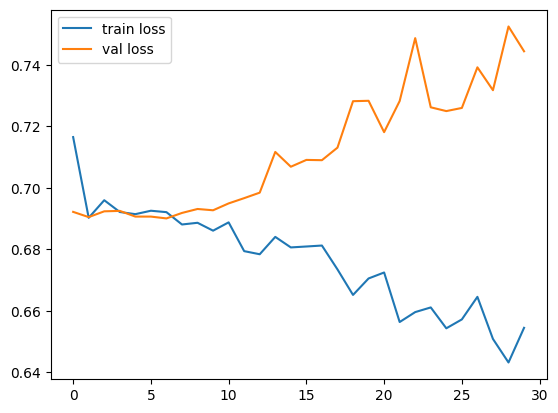

In [11]:
val_freq = 2
n_epochs = 30

model = Net().cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, ) # Slightly slower LR for stability
loss_function = torch.nn.BCEWithLogitsLoss()

model = train_medmnist(model, train_dataloader, val_dataloader, optimizer, epochs=n_epochs)

## 🏥 Hoe goed is onze AI-dokter? Performance evaluatie!

**Het moment van waarheid** 🎭 Onze AI heeft geleerd, maar hoe goed is het eigenlijk? In de echte wereld hangt er veel van af: we willen geen mensen met een litteken missen, maar ook geen gezonde mensen onnodig bang maken.

### 📊 De Belangrijkste Meetwaarden:

**🎯 Precision (Precisie):**
- Van alle mensen die de AI als "met litteken" bestempelt, hoeveel hebben er echt een?
- Hoge precisie = weinig "valse alarmen"

**🔍 Recall (Herinnering):**
- Van alle mensen met een litteken, hoeveel heeft de AI gevonden?
- Hoge recall = weinig gemiste behandelingen

### 🤔 De Balans:
- **Perfect precision maar lage recall:** AI is heel voorzichtig maar mist mensen met een behandeling
- **Perfect recall maar lage precision:** AI vindt alle mensen met een litteken maar geeft vaak vals alarm dat een persoon zonder een litteken wel eentje heeft.


![Precision vs Recall](https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/960px-Precisionrecall.svg.png)

### 📝 Testen: De eindexamens!

Nadat de AI getraind en gevalideerd is, komt het moment van de 'eindexamens': de testfase. Dit is de ultieme proef om te zien hoe goed de AI in de echte wereld zal presteren.

*   **De testdata is volledig nieuw:** Dit is een set foto's die de AI *nooit* heeft gezien, zelfs niet tijdens de validatie.
*   **Eerlijke evaluatie:** Omdat de AI deze data nog nooit heeft gezien, geeft de prestatie op de testset een zeer realistische inschatting van hoe goed de AI zal werken op onbekende data in de praktijk.
*   **Belangrijke metrieken:** We kijken naar metrics zoals `Precision`, `Recall` en de `Confusion Matrix` om een gedetailleerd beeld te krijgen van de prestaties van de AI-dokter.

In [12]:
# 🔮 AI-Dokter in Actie: Voorspellingen bekijken

def validation_results_visualize(model, dataset):
    # Kies een willekeurige afbeelding uit de dataset
    index = np.random.randint(0, len(dataset))
    sample = dataset[index]

    small_image = sample['img']
    label = sample['label']
    orig_img = sample['orig']

    # Toon de originele afbeelding
    plt.imshow(orig_img, cmap='gray')
    plt.yticks([]); plt.xticks([])

    # Converteer de verkleinde afbeelding naar een PyTorch tensor en verplaats naar GPU
    # model[0] is de daadwerkelijke Net() instantie
    image_t = small_image.float().to('cuda') # shape (1, 128, 128)

    with torch.no_grad():
         # Maak een voorspelling met het model en pas sigmoid toe om een waarschijnlijkheid te krijgen
         output = torch.sigmoid(model[0](image_t.unsqueeze(0))).item()

         # Bepaal de AI-voorspelling (0 voor geen kanaalbehandeling, 1 voor met kanaalbehandeling)
         ai_prediction = int(output >= 0.5)

         # Print het label van de afbeelding en de voorspelling
         print(f"Index: {index}, Werkelijk label: {label}, Waarschijnlijkheid: {output:.3f}, AI voorspelling: {ai_prediction}")
         plt.title(f"Werkelijk: {label}, AI Prob: {output:.3f}, AI Pred: {ai_prediction}")
         plt.show()

    # Retourneer of de AI-diagnose correct was
    return ai_prediction == label

/tmp/ipykernel_12896/2404688601.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


Index: 0, Werkelijk label: 0, Waarschijnlijkheid: 0.414, AI voorspelling: 0


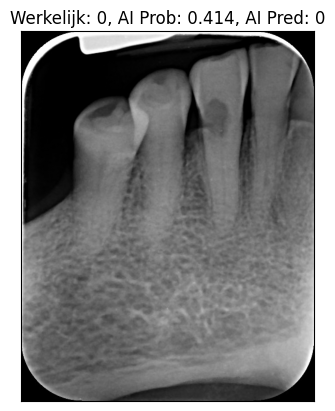

True

In [13]:
validation_results_visualize(model, test_dataset)

/tmp/ipykernel_12896/2404688601.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


🏥 Laten we onze AI-dokter 10 willekeurige patiënten laten bekijken!
   Kijk goed naar elke diagnose - klopt het wat de AI zegt?

🔍 AI-DOKTER DIAGNOSE SESSIE

👤 Patiënt #1:
Index: 70, Werkelijk label: 1, Waarschijnlijkheid: 0.460, AI voorspelling: 0


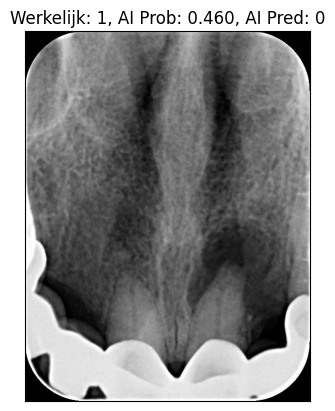

   ❌ AI-diagnose is incorrect!

👤 Patiënt #2:
Index: 60, Werkelijk label: 1, Waarschijnlijkheid: 0.499, AI voorspelling: 0


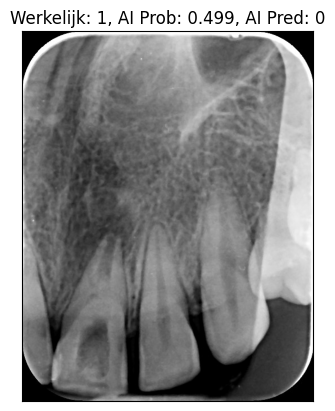

   ❌ AI-diagnose is incorrect!

👤 Patiënt #3:
Index: 9, Werkelijk label: 0, Waarschijnlijkheid: 0.636, AI voorspelling: 1


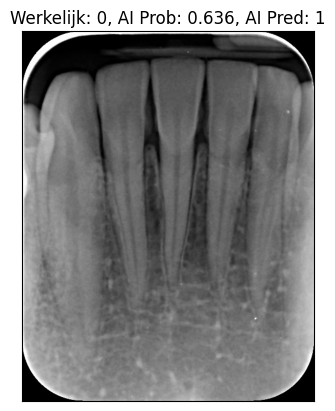

   ❌ AI-diagnose is incorrect!

👤 Patiënt #4:
Index: 40, Werkelijk label: 1, Waarschijnlijkheid: 0.468, AI voorspelling: 0


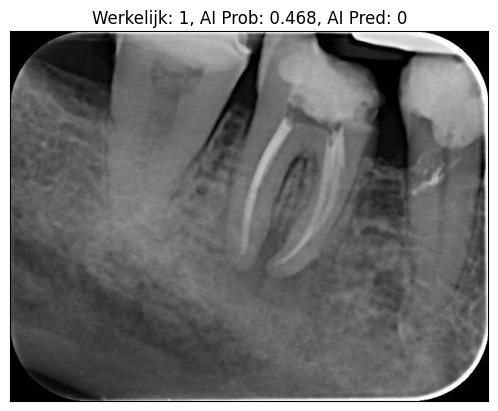

   ❌ AI-diagnose is incorrect!

👤 Patiënt #5:
Index: 16, Werkelijk label: 1, Waarschijnlijkheid: 0.520, AI voorspelling: 1


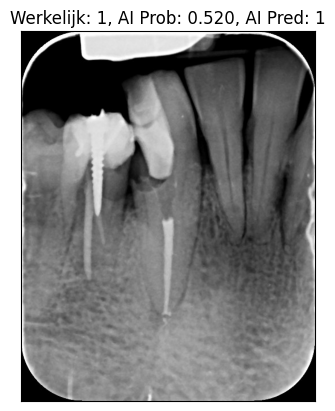

   ✅ AI-diagnose is correct!

👤 Patiënt #6:
Index: 27, Werkelijk label: 1, Waarschijnlijkheid: 0.378, AI voorspelling: 0


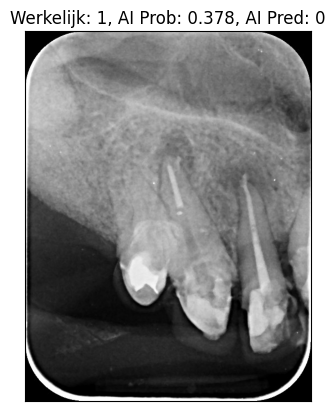

   ❌ AI-diagnose is incorrect!

👤 Patiënt #7:
Index: 29, Werkelijk label: 0, Waarschijnlijkheid: 0.554, AI voorspelling: 1


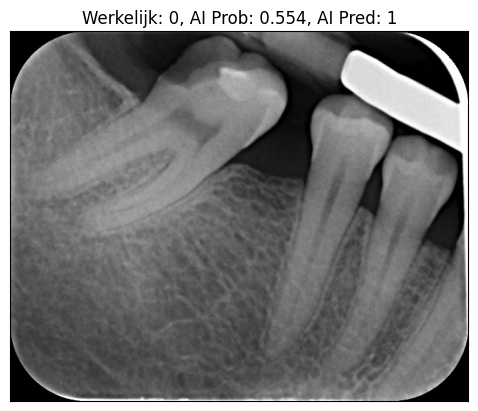

   ❌ AI-diagnose is incorrect!

👤 Patiënt #8:
Index: 11, Werkelijk label: 0, Waarschijnlijkheid: 0.363, AI voorspelling: 0


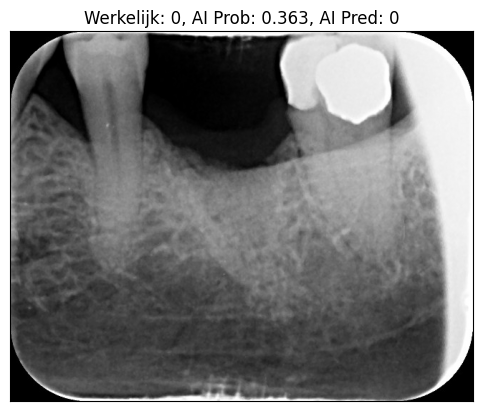

   ✅ AI-diagnose is correct!

👤 Patiënt #9:
Index: 45, Werkelijk label: 1, Waarschijnlijkheid: 0.361, AI voorspelling: 0


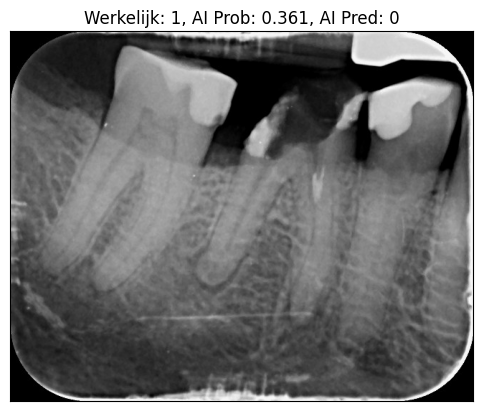

   ❌ AI-diagnose is incorrect!

👤 Patiënt #10:
Index: 70, Werkelijk label: 1, Waarschijnlijkheid: 0.460, AI voorspelling: 0


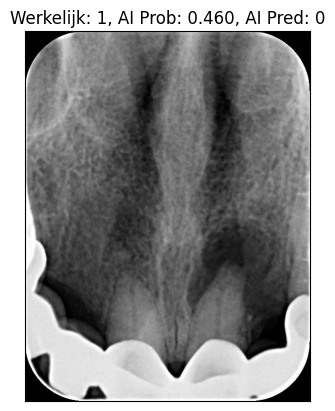

   ❌ AI-diagnose is incorrect!

📊 SESSION RESULTATEN:
🎯 Correcte diagnoses: 2 van 10
📈 Session Accuracy: 20.0%
🎓 Hmm, onze AI heeft nog meer training nodig!

💡 Tip: Run deze cel opnieuw voor andere willekeurige patiënten!


In [14]:
# 🎲 AI-Dokter Performance Test: 10 Willekeurige Diagnoses!

print("🏥 Laten we onze AI-dokter 10 willekeurige patiënten laten bekijken!")
print("   Kijk goed naar elke diagnose - klopt het wat de AI zegt?")

correct_predictions = 0
total_predictions = 10

print("\n" + "="*60)
print("🔍 AI-DOKTER DIAGNOSE SESSIE")
print("="*60)

for i in range(total_predictions):
    print(f"\n👤 Patiënt #{i+1}:")
    is_correct = validation_results_visualize(model, val_dataset)

    if is_correct:
        correct_predictions += 1
        print("   ✅ AI-diagnose is correct!")
    else:
        print("   ❌ AI-diagnose is incorrect!")

# Bereken de accuracy
accuracy = (correct_predictions / total_predictions) * 100

print("\n" + "="*60)
print("📊 SESSION RESULTATEN:")
print("="*60)
print(f"🎯 Correcte diagnoses: {correct_predictions} van {total_predictions}")
print(f"📈 Session Accuracy: {accuracy:.1f}%")

if accuracy >= 80:
    print("🌟 Geweldig! Onze AI-dokter presteert uitstekend!")
elif accuracy >= 70:
    print("👍 Goed! Onze AI-dokter doet het aardig goed!")
elif accuracy >= 60:
    print("📚 Oké - onze AI kan nog wel wat meer leren...")
else:
    print("🎓 Hmm, onze AI heeft nog meer training nodig!")

print(f"\n💡 Tip: Run deze cel opnieuw voor andere willekeurige patiënten!")

In [18]:
# 📊 Precision & Recall Calculator: Hoe Goed is Onze AI Echt?

threshold  = 0.5 # Drempelwaarde voor classificatie: alles boven deze waarde wordt als 'positief' beschouwd

def get_precision_recall(model, dataloader):
    # Zet het model in evaluatiemodus (belangrijk voor Dropout en BatchNorm lagen)
    model[0].eval()
    TP, TN, FP, FN = 0, 0, 0, 0 # Initialiseer tellers voor True Positives, True Negatives, False Positives, False Negatives

    with torch.no_grad(): # Schakel gradientberekening uit om geheugen en rekentijd te besparen
         for batch in dataloader:
             images = batch['img'].float().to('cuda') # Verplaats afbeeldingen naar GPU
             labels = batch['label'].float().to('cuda') # Verplaats labels naar GPU
             labels = labels.unsqueeze(1) # Voeg een dimensie toe aan labels om overeen te komen met de output van het model

             # Voer de afbeeldingen door het model en pas sigmoid toe om waarschijnlijkheden te krijgen
             outputs = torch.sigmoid(model[0](images)) # model[0] is de daadwerkelijke Net() instantie

             # Converteer waarschijnlijkheden naar binaire voorspellingen op basis van de drempelwaarde
             preds = (outputs >= threshold).float()

             # Update de tellers
             TP += ((preds == 1) & (labels == 1)).sum().item()
             TN += ((preds == 0) & (labels == 0)).sum().item()
             FP += ((preds == 1) & (labels == 0)).sum().item()
             FN += ((preds == 0) & (labels == 1)).sum().item()

    # Bereken Precision en Recall
    precision = TP / (TP + FP + 1e-8) # Voeg een kleine waarde toe om deling door nul te voorkomen
    recall = TP / (TP + FN + 1e-8) # Voeg een kleine waarde toe om deling door nul te voorkomen

    return precision, recall

# Maak een DataLoader voor de testdataset
test_loader = monai.data.DataLoader(test_dataset, batch_size = 32, shuffle=False, collate_fn=collate_without_orig)
# Bereken Precision en Recall
precision, recall = get_precision_recall(model, test_loader)
print(f'Het precision van het model is {precision:.2f}, het recall van het model is {recall:.2f}.')

Het precision van het model is 0.47, het recall van het model is 0.57.


/tmp/ipykernel_12896/2404688601.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


/tmp/ipykernel_12896/2404688601.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self.labels[idx])


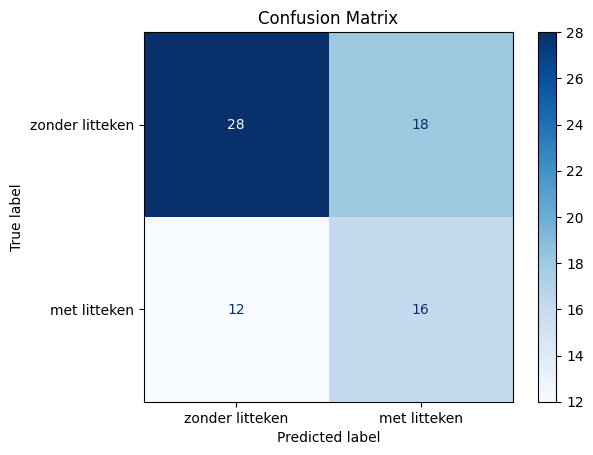

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, dataloader):
    """
    Plots a confusion matrix using true and predicted labels.

    :param y_true: List or array of true labels.
    :param y_pred: List or array of predicted labels.
    :param labels: List of label names (optional).
    """
    model[0].eval()
    true_labels = []
    predicted_labels = []


    for data in dataloader:
        images = data['img'].float().to('cuda')
        labels = data['label'].cpu().numpy()
        with torch.no_grad():
            output = torch.sigmoid(model[0](images)).cpu().numpy().flatten()
        pred_classes = (output >= 0.5).astype(int)
        true_labels.extend(labels)
        predicted_labels.extend(pred_classes)

    cm = confusion_matrix(true_labels, predicted_labels, labels=[0,1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['zonder litteken', 'met litteken'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(model, test_loader)

## 🤔 Reflectie: Wat vind je van de resultaten?

**Denk er eens over na:** Onze AI heeft zojuist duizenden röntgenfoto's beoordeeld. Wat vind je van de precision en recall scores?

### 🧠 Belangrijke Vragen:
1. **Welke precisie is goed genoeg voor litteken diagnoses?**
2. **Wat zou er gebeuren als onze AI 20% van de littekens mist?**
3. **Zou je willen dat een AI jouw röntgenfoto beoordeelt?**

### 💭 Context:
- Het detecteren van littekens is best uitdagend in de praktijk. De precisie van dokters kan rond de 80% liggen.
- In de echte wereld wordt AI vaak gebruikt als "tweede mening" naast een dokter
- Echte medische AI is gebaseerd op veel grotere en gedetailleerdere foto's dan die wij gebruikten, en kan daardoor beter littekens vinden.

**Wat denk jij? Vertrouw je onze AI-dokter?** 🤖👨‍⚕️

## 🔍 Confusion Matrix

**Wat is een Confusion Matrix?** 🤯 Het is een handige tabel die PRECIES laat zien waar onze AI goed in is en waar het fouten maakt.

### 📊 Hoe lees je het:
- **Linksboven:** Mensen zonder een litteken die terecht zonder een litteken gediagnosticeerd zijn ✅
- **Rechtsonder:** Mensen met een litteken die terecht met een litteken gediagnosticeerd zijn ✅  
- **Rechtsboven:** Mensen zonder een litteken die ten onrechte met een litteken bestempeld zijn ❌ (Vals alarm!)
- **Linksonder:** Mensen met een litteken die gemist zijn ❌ (Gevaarlijk!)

### 🏥 Medische Impact:
- **Vals alarm (rechtsboven):** Onnodige stress en extra tests
- **Gemiste diagnose (linksonder):** Potentieel levensgevaarlijk!

## 📝 Vragen voor de studenten:


1.  **Precisie en Recall:**
    *   Wat waren de `Precision` en `Recall` scores van onze AI op de testdata? (Je kunt de cel `hc0qVC30y140` opnieuw uitvoeren om de exacte getallen te zien.)
    *   Leg in je eigen woorden uit wat het verschil is tussen Precisie en Recall.
    *   Stel dat je een AI traint die gevaarlijke explosieven moet detecteren. Zou je dan een hogere prioriteit geven aan `Precision` of aan `Recall`? Waarom?
    *   Stel dat je een AI traint die spamfilters moet maken voor e-mail. Zou je dan een hogere prioriteit geven aan `Precision` of aan `Recall`? Waarom?

2.  **Confusion Matrix:**
    *   Kijk nog eens goed naar de Confusion Matrix. Welke fouten maakt de AI het meest? Zijn dit vals positieven (mensen zonder litteken die ten onrechte als 'met' worden bestempeld) of vals negatieven (mensen met litteken die gemist worden)?
    *   Wat zijn de mogelijke gevolgen van deze specifieke fouten in de context van een medische diagnose zoals een litteken?

3.  **Ethische overwegingen:**
    *   Vind je dat deze AI al 'klaar' is voor gebruik in een echte tandartspraktijk? Waarom wel of waarom niet?
    *   Welke aanvullende informatie of testen zou je willen hebben voordat je de AI vertrouwt met echte patiënten?

4.  **Overfitting en Validatie:**

    *   Waarom is het zo belangrijk om een aparte validatieset te hebben en niet alleen naar de trainingsdataset te kijken.


## Vragen en uitwerking ✍️
  
Werk deze vragen uit in **tekstblokken (Markdown‑cellen)**, niet in code. Klik op het + teken in het menu boven waar **Text** staat, dan verschijnt een tekst-cel waar je je antwoorden kan schrijven.

👥 Doe dit in **paren**: bespreek samen de antwoorden en noteer ze in de notebook.  
💾 Als jullie klaar zijn, download de notebook als `.ipynb` bestand  
(via *File → Download → Download .ipynb*)  
📧 Stuur dit bestand vervolgens naar n.j.starreveld@uva.nl.

Belangrijk: het gaat om jullie **reflectie en uitleg**, niet om perfecte antwoorden!

## AI-Statement van de auteurs

Deze Notebook werd ontwikkeld door Clara Stegehuis en Dieuwertje Albas van de Universiteit Twente. Nicos Starreveld heeft vooral gekeken naar de didactiek van de opdracht en heeft stukken aangepast opdat de Notebook beter aansluit op de behoeftes van leerlingen. De ingebouwde functie van Gemini is gebruikt door Starreveld om de code te verbeteren en om de toelichtingen bij "Training: De AI leert van voorbeelden", "Overfitting voorkomen met Validatie" en "Validatie: Controle tijdens het leren" te schrijven. Gemini is vooral gebruikt om wille van de tijd om de opdracht te verbeteren. In de eerste versies van deze opdracht zagen we dat het model heel snel aan het overfitten was, we vroegen Gemini om te kijken of de kleine dataset het reden was hiervoor. Gemini stelde een aanpassing voor aan de structuur van het CNN. Gemini stelde voor om de gewichten van knopen op willekeurige momenten te resetten, wat de prestatie van het CNN zou verbeteren. We hebben deze aanpassing geprobeerd maar we hebben gemerkt dat het CNN hierdoor alle nieuwe afbeeldingen classificieerde als positief (er is een litteken). Deze suggestie van Gemini hebben we dus niet geaccepteerd. Dit laat zien dat we heel zorgvuldig om moeten gaan met GenAI tools.